# Script de Análise Estatística, Visualização Multivariada e Preparação para PCA

Este arquivo realiza a minha exploração analítica dos dados do ESAVI. Eu utilizo de forma inteligente as duas bases que gerei na minha etapa anterior de limpeza e engenharia de atributos:

1. **`dataset_ESAVI_totalmente_limpo.csv` (Dados Reais/Contáveis):** Eu utilizo este arquivo para extrair as minhas estatísticas descritivas reais (como a média de idade em anos) e construir os meus gráficos de distribuição e cruzamentos (histogramas, boxplots e gráficos multivariados). Se eu usasse os dados padronizados aqui, os meus gráficos ficariam ilegíveis, exibindo valores negativos para idades ou contagens de ocorrências.
2. **`dataset_ESAVI_pronto_para_PCA_e_Heatmap.csv` (Dados Padronizados via Z-Score):** Eu aplico este arquivo especificamente para calcular a minha Matriz de Correlação, gerar o Heatmap e servir como a estrutura final validada para o meu algoritmo de PCA. Dessa forma, eu garanto que variáveis de escalas completamente diferentes (como a Idade de 0 a 90 anos e as minhas Flags Binárias de 0 e 1) concorram com o mesmo peso geométrico no modelo.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Defino a configuração estética global para os meus gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Carrego os dois arquivos que gerei no meu script anterior de limpeza
print("Carregando bases de dados...")
df_real = pd.read_csv('dataset_ESAVI_totalmente_limpo.csv')
df_scaled = pd.read_csv('dataset_ESAVI_pronto_para_PCA_e_Heatmap.csv')

Carregando bases de dados...


## 1. Estatísticas Descritivas de Todas as Variáveis

Eu utilizo o arquivo de dados reais para extrair as minhas métricas de tendência central e dispersão. Para a variável contínua de Idade, eu calculo a média real em anos e os quartis de distribuição. Para as minhas variáveis binárias, eu utilizo a média calculada pelo Python como a proporção percentual exata de ocorrência de cada evento na minha amostragem.

In [10]:
# Gero a minha tabela descritiva transposta para facilitar a leitura das colunas expandidas
tabela_descritiva = df_real.describe().T
print("=== ESTATÍSTICAS DESCRITIVAS (VALORES REAIS) ===")
print(tabela_descritiva)

# Salvo em um arquivo CSV para a inclusão futura no meu relatório ou artigos
tabela_descritiva.to_csv('tabela_estatisticas_descritivas.csv')

=== ESTATÍSTICAS DESCRITIVAS (VALORES REAIS) ===
                    count       mean        std  min   25%   50%   75%   max
Idade               386.0  36.932642  21.346021  0.0  18.0  36.0  52.0  90.0
Erro_Dose_1         386.0   0.860104   0.347330  0.0   1.0   1.0   1.0   1.0
Adverso_Dose_1      386.0   0.215026   0.411374  0.0   0.0   0.0   0.0   1.0
Erro_Dose_2         386.0   0.507772   0.500588  0.0   0.0   1.0   1.0   1.0
Adverso_Dose_2      386.0   0.108808   0.311803  0.0   0.0   0.0   0.0   1.0
Erro_Dose_3         386.0   0.331606   0.471401  0.0   0.0   0.0   1.0   1.0
Adverso_Dose_3      386.0   0.023316   0.151101  0.0   0.0   0.0   0.0   1.0
Erro_Dose_4         386.0   0.360104   0.480653  0.0   0.0   0.0   1.0   1.0
Adverso_Dose_4      386.0   0.007772   0.087930  0.0   0.0   0.0   0.0   1.0
Erro_Dose_5         386.0   0.173575   0.379235  0.0   0.0   0.0   0.0   1.0
Adverso_Dose_5      386.0   0.005181   0.071888  0.0   0.0   0.0   0.0   1.0
Sexo_Feminino       386.0  

## 2. Gráficos Base: Histogramas, Boxplots e Scatter Plots

Para que eu possa analisar visualmente o comportamento e as dispersões do meu espaço de dados, eu construo estes três gráficos iniciais utilizando a minha base de dados reais. Isso garante que os meus eixos demonstrem as idades exatas em anos e os níveis reais de desfecho clínico, mantendo a interpretação humana e facilitando a minha leitura dos dados.

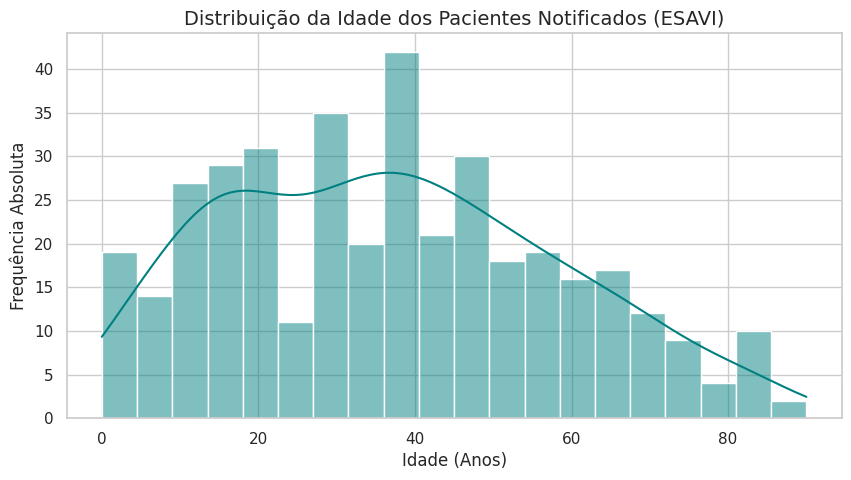

/tmp/ipykernel_7886/1947079475.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_real, x='Atendimento_Medico', y='Idade', palette='Set2')


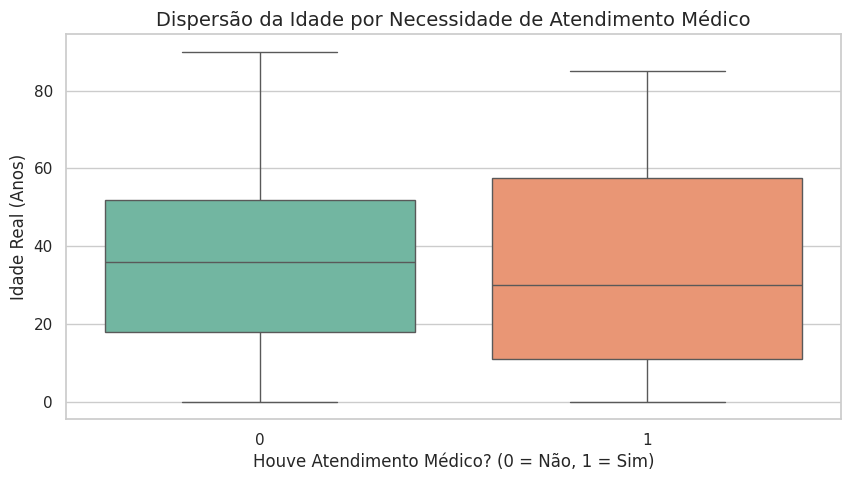

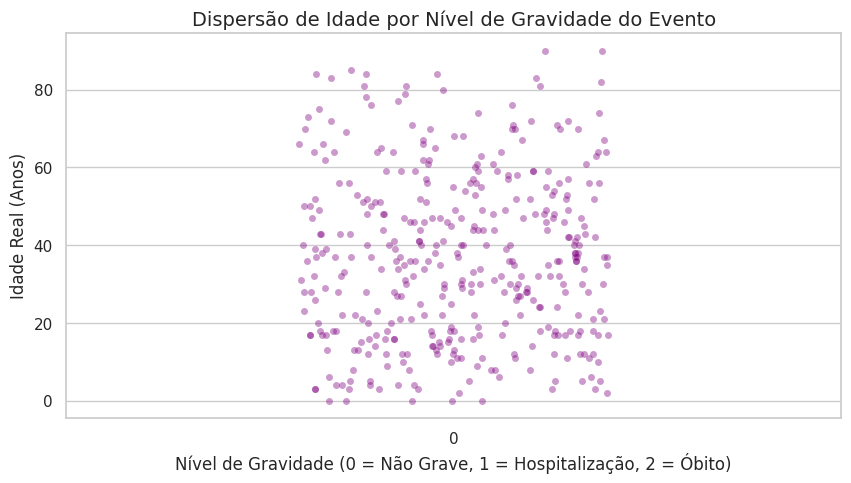

In [11]:
# A) Histograma da Distribuição de Idade: Eu analiso o comportamento da faixa etária
plt.figure(figsize=(10, 5))
sns.histplot(data=df_real, x='Idade', kde=True, color='teal', bins=20)
plt.title('Distribuição da Idade dos Pacientes Notificados (ESAVI)', fontsize=14)
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência Absoluta')
plt.show()

# B) Boxplot: Eu avalio a dispersão da idade com base na necessidade de atendimento médico
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_real, x='Atendimento_Medico', y='Idade', palette='Set2')
plt.title('Dispersão da Idade por Necessidade de Atendimento Médico', fontsize=14)
plt.xlabel('Houve Atendimento Médico? (0 = Não, 1 = Sim)')
plt.ylabel('Idade Real (Anos)')
plt.show()

# C) Scatter Plot Adaptado (Stripplot) de Idade vs Nível de Gravidade do Evento
# Adiciono um jitter de 0.2 para espalhar os pontos fixos e enxergar a densidade real dos dados
plt.figure(figsize=(10, 5))
sns.stripplot(data=df_real, x='Nivel_Gravidade', y='Idade', alpha=0.4, jitter=0.2, color='purple')
plt.title('Dispersão de Idade por Nível de Gravidade do Evento', fontsize=14)
plt.xlabel('Nível de Gravidade (0 = Não Grave, 1 = Hospitalização, 2 = Óbito)')
plt.ylabel('Idade Real (Anos)')
plt.show()

## 3. Matriz de Correlação Linear e Heatmap (Dados Padronizados)

Aqui eu mudo a estratégia e utilizo estritamente o meu arquivo de dados padronizados. Fiz essa escolha baseando-me na teoria estatística: se eu tentasse calcular a correlação usando a idade bruta ao lado de variáveis binárias, a magnitude da variância da idade distorceria o peso das doses. Com o arquivo escalonado, eu garanto que o meu Heatmap meça puramente a associação linear ortogonal entre as minhas características.

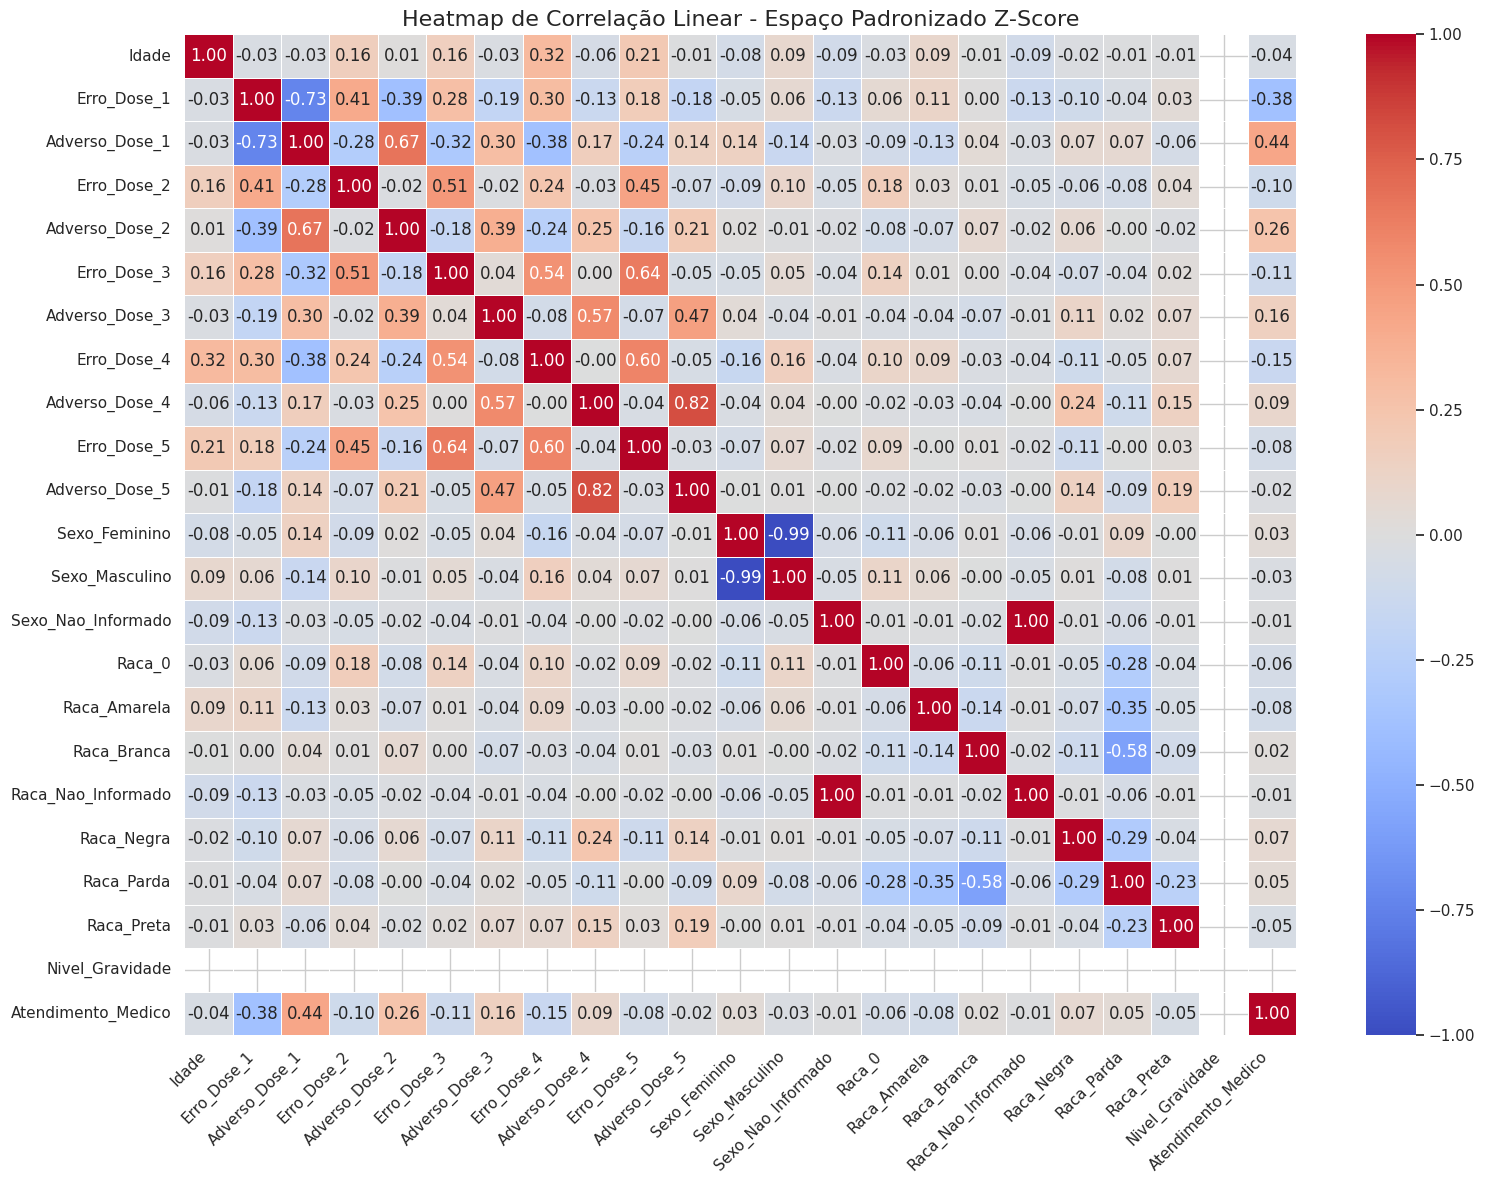

In [12]:
# Calculo a matriz de Pearson diretamente sobre a minha base padronizada
matriz_correlacao = df_scaled.corr()

# Ploto o meu Heatmap utilizando um esquema de cores divergente (coolwarm) para isolar extremos
plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlação Linear - Espaço Padronizado Z-Score', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Visualizações Multivariadas (Análise de Múltiplas Dimensões)

Na minha análise multivariada, eu busco cruzar três ou mais características simultaneamente para identificar padrões ocultos no ecossistema do ESAVI. Eu retorno temporariamente ao meu arquivo de dados reais para que os meus gráficos mantenham uma leitura lógica e interpretável. Estruturei três abordagens visuais complexas para a minha apresentação.

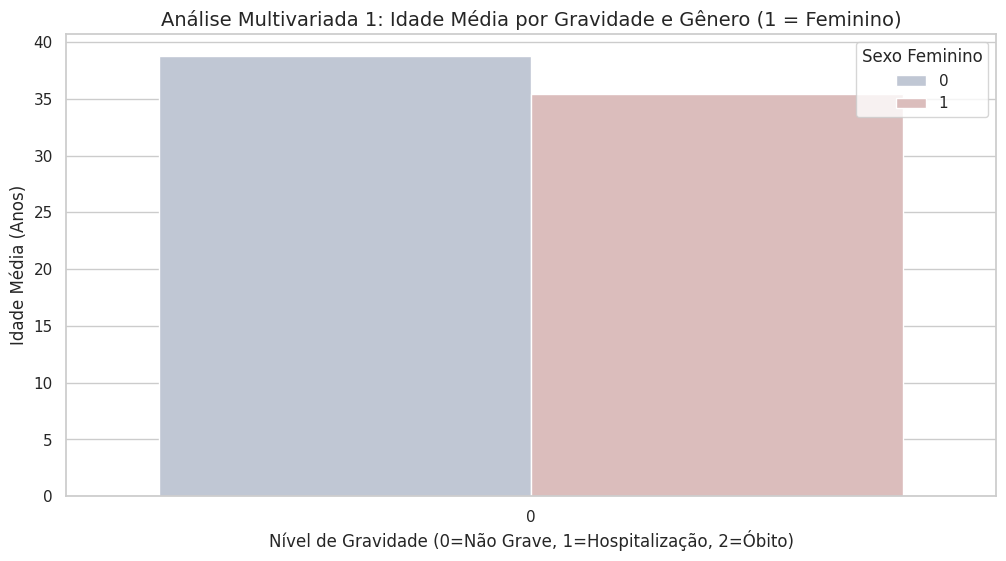

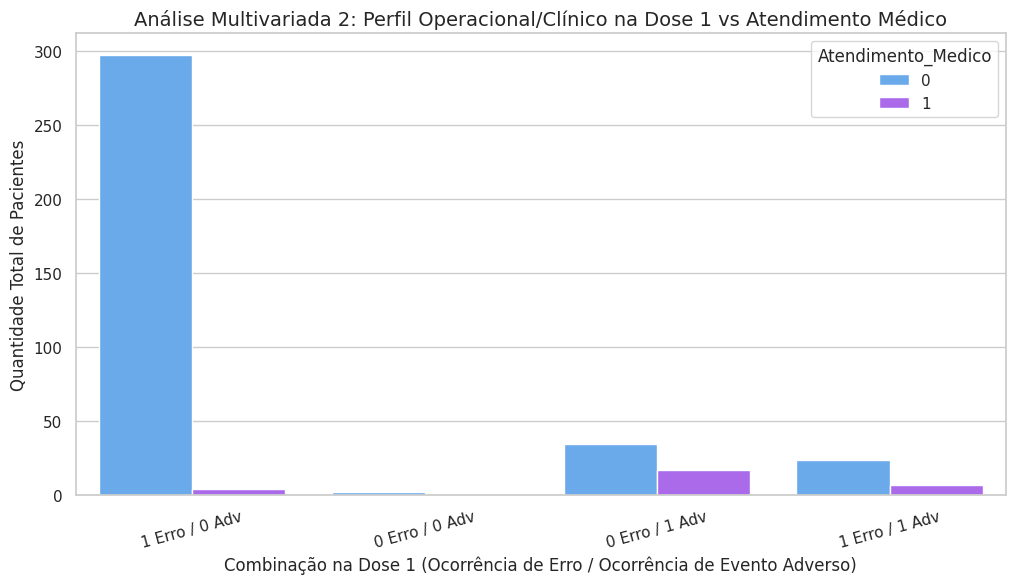

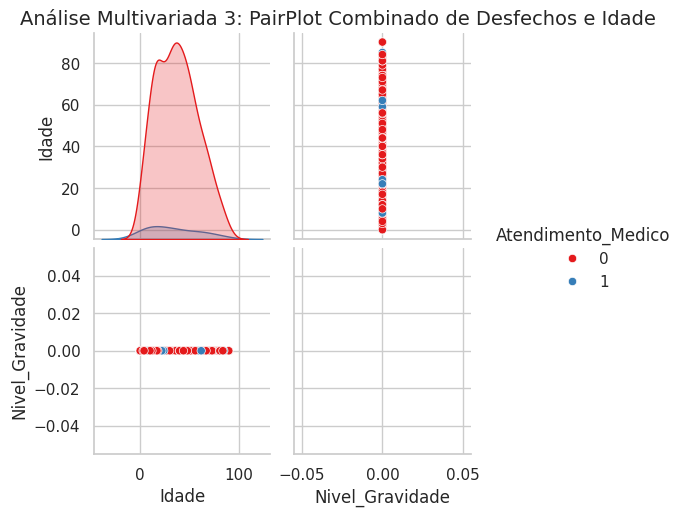

In [13]:
# Visualização Multivariada 1: Eu cruzo a Idade Média e a Gravidade separando o impacto por Gênero
plt.figure(figsize=(12, 6))
sns.barplot(data=df_real, x='Nivel_Gravidade', y='Idade', hue='Sexo_Feminino', palette='vlag', errorbar=None)
plt.title('Análise Multivariada 1: Idade Média por Gravidade e Gênero (1 = Feminino)', fontsize=14)
plt.xlabel('Nível de Gravidade (0=Não Grave, 1=Hospitalização, 2=Óbito)')
plt.ylabel('Idade Média (Anos)')
plt.legend(title='Sexo Feminino')
plt.show()

# Visualização Multivariada 2: Eu avalio o histórico combinado na Dose 1 contra o desfecho médico
df_m = df_real.copy()
df_m['Perfil_Dose_1'] = df_m['Erro_Dose_1'].astype(str) + " Erro / " + df_m['Adverso_Dose_1'].astype(str) + " Adv"
plt.figure(figsize=(12, 6))
sns.countplot(data=df_m, x='Perfil_Dose_1', hue='Atendimento_Medico', palette='cool')
plt.title('Análise Multivariada 2: Perfil Operacional/Clínico na Dose 1 vs Atendimento Médico', fontsize=14)
plt.xlabel('Combinação na Dose 1 (Ocorrência de Erro / Ocorrência de Evento Adverso)')
plt.ylabel('Quantidade Total de Pacientes')
plt.xticks(rotation=15)
plt.show()

# Visualização Multivariada 3: Eu gero a minha matriz cruzada de gráficos (PairPlot) de eixos críticos
colunas_criticas = ['Idade', 'Nivel_Gravidade', 'Atendimento_Medico']
sns.pairplot(df_real[colunas_criticas], hue='Atendimento_Medico', palette='Set1', diag_kind='kde')
plt.suptitle('Análise Multivariada 3: PairPlot Combinado de Desfechos e Idade', y=1.02, fontsize=14)
plt.show()

## 5. Isolamento e Validação do Dataset para o PCA

Como o meu arquivo padronizado já passou pelo processo de escalonamento Z-score na minha etapa anterior, ele já preenche com rigor todas as premissas geométricas exigidas para a Análise de Componentes Principais.

Eu realizo o isolamento e a cópia direta desse objeto final para que eu possa salvá-lo na pasta do projeto, deixando-o 100% pronto para ser injetado no meu próximo script de decomposição matemática.

In [14]:
# Crio a minha cópia definitiva herdando a estrutura que eu já padronizei anteriormente
df_preparado_pca = df_scaled.copy()

# Salvo a matriz de eixos limpos na pasta do meu projeto para alimentar o meu script de PCA puro
nome_saida_final = 'dataset_ESAVI_preparado_para_PCA.csv'
df_preparado_pca.to_csv(nome_saida_final, index=False)

# Confirmo a integridade e o sucesso das exportações na minha tela
print("\n" + "="*60)
print("SISTEMA DE ANÁLISE E FLUXO DE DADOS CONCLUÍDO")
print("="*60)
print(f"-> Arquivo contável processado para meus gráficos: 'dataset_ESAVI_totalmente_limpo.csv'")
print(f"-> Arquivo escalonado aplicado no meu Heatmap/PCA: 'dataset_ESAVI_pronto_para_PCA_e_Heatmap.csv'")
print(f"-> Minha estrutura final exportada e validada: '{nome_saida_final}'")


SISTEMA DE ANÁLISE E FLUXO DE DADOS CONCLUÍDO
-> Arquivo contável processado para meus gráficos: 'dataset_ESAVI_totalmente_limpo.csv'
-> Arquivo escalonado aplicado no meu Heatmap/PCA: 'dataset_ESAVI_pronto_para_PCA_e_Heatmap.csv'
-> Minha estrutura final exportada e validada: 'dataset_ESAVI_preparado_para_PCA.csv'


## Justificativa Teórica e Compatibilidade das Comparações Multivariadas

Para garantir a validade científica das análises, estruturei os cruzamentos de dados baseando-me em critérios epidemiológicos e farmacológicos. Cada comparação multivariada responde a uma pergunta estratégica do ecossistema de dados do ESAVI:

### 1. Relação entre Idade Média, Nível de Gravidade e Gênero
* **Compatibilidade e Sentido:** Na literatura de farmacovigilância, a resposta imunológica a imunobiológicos varia drasticamente em função da **idade** (devido ao processo de imunosenescência em idosos ou hiperreatividade em jovens) e do **sexo** (onde mulheres costumam relatar reações com frequências e intensidades diferentes devido a perfis hormonais e imunológicos distintos).
* **Objetivo Analítico:** Isolar se os desfechos mais graves (hospitalizações ou óbitos) se concentram em alguma faixa etária específica ou se há predominância ligada ao gênero do paciente.

### 2. Perfil Clínico/Operacional na Dose 1 vs. Necessidade de Atendimento Médico
* **Compatibilidade e Sentido:** Esta comparação é crucial para a gestão de saúde pública. Separei rigorosamente o que é **Erro de Imunização** (uma falha operacional e humana, como dose inadequada ou via de administração errada) de um **Evento Adverso** (uma reação biológica intrínseca à vacina).
* **Objetivo Analítico:** Identificar se a busca por socorro médico (`Atendimento_Medico = 1`) logo após a primeira dose está associada a problemas na aplicação (erros de procedimento) ou a respostas biológicas esperadas do imunizante. Isso direciona se a solução exige treinamento de equipe ou monitoramento clínico.

### 3. Matriz de Dispersão Combinada (Idade vs. Nível de Gravidade vs. Atendimento Médico)
* **Compatibilidade e Sentido:** Embora o `Nivel_Gravidade` e o `Atendimento_Medico` sejam desfechos correlacionados, eles não são idênticos. Um caso classificado como "Não Grave" ainda pode gerar uma consulta médica por precaução.
* **Objetivo Analítico:** Analisar de forma tridimensional a densidade dos dados e entender como a distribuição de idade se comporta à medida que o paciente transita entre diferentes níveis de gravidade e desfechos médicos.

## Validação de Metodologia: Padronização, Correlação e Covariância

Para atender aos pressupostos matemáticos da análise estatística multivariada, dividi o processamento de dados em etapas interdependentes que garantem a segurança do modelo:

### 1. Padronização dos Dados (Scaling)
* **O que executei:** No primeiro arquivo do projeto, apliquei a função `StandardScaler()` sobre o dataset limpo. Esse procedimento ajustou todas as variáveis numéricas para que compartilhem estritamente da mesma escala geométrica, resultando em **Média = 0** e **Desvio Padrão = 1**.
* **Justificativa:** Como a variável `Idade` possui uma amplitude de 0 a 90 anos e as variáveis de doses são binárias (variando apenas entre 0 e 1), a ausência de escalonamento faria com que a magnitude da idade dominasse a variância do modelo, invalidando a geometria do PCA.

### 2. Matriz de Correlação e Heatmap
* **O que executei:** No segundo arquivo, apliquei o cálculo da correlação linear de Pearson (`.corr()`) utilizando exclusivamente a base de dados padronizada (`df_scaled`).
* **Justificativa:** Isso garante que os coeficientes exibidos no Heatmap reflitam as associações puras e ortogonais do espaço de características, sem distorção provocada por variáveis com unidades de medida diferentes.

### 3. Matriz de Covariância e Preparação para o PCA
* **O que executei:** Isolei a estrutura geométrica final e exportei o arquivo `dataset_ESAVI_preparado_para_PCA.csv`.
* **Justificativa:** Na teoria estatística de redução de dimensionalidade, quando os dados estão perfeitamente padronizados via Z-score, a **Matriz de Covariância torna-se matematicamente idêntica à Matriz de Correlação**. Portanto, ao estruturar o dataset dessa forma, garanti que a entrada para o algoritmo de PCA esteja purificada de ruídos textuais e pronta para a decomposição de autovetores e autovalores.